In [8]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════════════
# TIỀN XỬ LÝ DỮ LIỆU SÁCH SAU KHI GỘP RATINGS
# Input:  books_with_ratings.csv  (output của merge_books_ratings.py)
# Output: books_cleaned_final.csv
# ══════════════════════════════════════════════════════════════════════════════

# ── LOAD ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("books_with_ratings.csv", low_memory=False)
print(f"{'='*55}")
print(f"  PHÂN TÍCH DỮ LIỆU ĐẦU VÀO")
print(f"{'='*55}")
print(f"Shape ban đầu: {df.shape[0]:,} cuốn × {df.shape[1]} cột")

# ── PHÂN TÍCH 1: Missing values ───────────────────────────────────────────────
print(f"\n── 1. Missing values ──")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
for col in df.columns:
    if missing[col] > 0:
        print(f"  {col:<25} {missing[col]:>5} ({missing_pct[col]}%)")
print(f"  (rating_std NaN là bình thường: sách chỉ có đúng 1 rating không tính được std)")

# ── PHÂN TÍCH 2: Year-Of-Publication ─────────────────────────────────────────
print(f"\n── 2. Year-Of-Publication ──")
df['age_of_book'] = 2024 - df['Year-Of-Publication']
print(f"  Năm nhỏ nhất: {int(df['Year-Of-Publication'].min())}")
print(f"  Năm lớn nhất: {int(df['Year-Of-Publication'].max())}")
bad_year = df[~df['Year-Of-Publication'].between(1800, 2024)]
print(f"  Năm bất thường (<1800 hoặc >2024): {len(bad_year)}")

# ── PHÂN TÍCH 3: Description ──────────────────────────────────────────────────
print(f"\n── 3. Độ dài description (số từ) ──")
df['words_in_description'] = df['description'].str.split().str.len()
desc_stats = df['words_in_description'].describe()
print(f"  Mean:   {desc_stats['mean']:.0f} từ")
print(f"  Median: {desc_stats['50%']:.0f} từ")
print(f"  Min:    {int(desc_stats['min'])} từ")
print(f"  Max:    {int(desc_stats['max'])} từ")
print(f"  1–4   từ: {df['words_in_description'].between(1,4).sum():>5} cuốn  → quá ngắn, bỏ")
print(f"  5–14  từ: {df['words_in_description'].between(5,14).sum():>5} cuốn  → quá ngắn, bỏ")
print(f"  15–24 từ: {df['words_in_description'].between(15,24).sum():>5} cuốn  → borderline, bỏ")
print(f"  ≥25   từ: {(df['words_in_description'] >= 25).sum():>5} cuốn  → giữ lại")
print()
print("  Ví dụ description 5–14 từ (sẽ bị loại):")
for s in df[df['words_in_description'].between(5,14)]['description'].head(3):
    print(f"    - {s}")

# ── PHÂN TÍCH 4: Duplicates ───────────────────────────────────────────────────
print(f"\n── 4. Duplicates ──")
dup_isbn13 = df['ISBN13'].duplicated(keep=False).sum()
dup_ta     = df.duplicated(subset=['Book-Title','Book-Author'], keep=False).sum()
print(f"  Duplicate ISBN13 (khác hoa/thường ISBN-10): {dup_isbn13} hàng → giữ bản rating cao hơn")
print(f"  Duplicate Title+Author (khác edition/năm):  {dup_ta} hàng → gộp rating, giữ bản phổ biến nhất")

# ── PHÂN TÍCH 5: Correlation ──────────────────────────────────────────────────
print(f"\n── 5. Spearman correlation (các cột số) ──")
num_cols = ['age_of_book','rating_count','rating_mean','weighted_rating',
            'implicit_count','total_readers','words_in_description']
corr = df[num_cols].corr(method='spearman').round(2)
print(corr.to_string())
print()
print("  Nhận xét:")
print("  - rating_count ↔ total_readers: 0.92  → hai cột gần như đo cùng một thứ")
print("  - implicit_count ↔ total_readers: 0.97 → sách phổ biến có cả implicit lẫn explicit cao")
print("  - age_of_book không tương quan mạnh với bất kỳ cột nào → sách cũ/mới đều có thể nổi tiếng")

# ══════════════════════════════════════════════════════════════════════════════
#   XỬ LÝ & LÀM SẠCH
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print(f"  LÀM SẠCH DỮ LIỆU")
print(f"{'='*55}")

n0 = len(df)

# Bước 1: Lọc description ≥ 25 từ
df = df[df['words_in_description'] >= 25].copy()
print(f"[1] Lọc description ≥25 từ:        {n0:>5} → {len(df):>5}  (bỏ {n0-len(df)})")

# Bước 2: Dedup ISBN13 (khác hoa/thường → cùng sách)
n1 = len(df)
df = df.sort_values('rating_count', ascending=False).drop_duplicates(subset='ISBN13', keep='first')
print(f"[2] Dedup ISBN13:                   {n1:>5} → {len(df):>5}  (bỏ {n1-len(df)})")

# Bước 3: Dedup title+author (khác edition)
# → gộp rating của tất cả editions, giữ metadata edition phổ biến nhất
n2 = len(df)
agg = df.groupby(['Book-Title','Book-Author']).agg(
    rating_count   = ('rating_count',   'sum'),
    implicit_count = ('implicit_count', 'sum'),
    total_readers  = ('total_readers',  'sum'),
    rating_mean    = ('rating_mean',    lambda x: (x * df.loc[x.index,'rating_count']).sum()
                                                   / max(df.loc[x.index,'rating_count'].sum(), 1)),
).reset_index()

df = df.sort_values('rating_count', ascending=False).drop_duplicates(
    subset=['Book-Title','Book-Author'], keep='first'
)
df = df.drop(columns=['rating_count','implicit_count','total_readers','rating_mean'])
df = df.merge(agg, on=['Book-Title','Book-Author'], how='left')
print(f"[3] Dedup Title+Author (gộp rating): {n2:>5} → {len(df):>5}  (bỏ {n2-len(df)})")

# Bước 4: Tính lại weighted_rating sau khi gộp
C = 7.68  # global mean
m = 5     # ngưỡng tối thiểu
df['weighted_rating'] = (
    (df['rating_count'] * df['rating_mean'] + m * C) / (df['rating_count'] + m)
).round(2)
df['rating_mean'] = df['rating_mean'].round(2)

# Fill NaN cho sách không có explicit rating nào
df['weighted_rating'] = df['weighted_rating'].fillna(C)
df['rating_mean']     = df['rating_mean'].fillna(C)

# Bước 5: Tạo tagged_description (isbn13 + description) cho vector search
df['tagged_description'] = df['ISBN13'].astype(str) + ' ' + df['description']

# Bước 6: Drop cột phụ trợ
df = df.drop(columns=['age_of_book', 'words_in_description'])

# ══════════════════════════════════════════════════════════════════════════════
#   THỐNG KÊ KẾT QUẢ
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print(f"  KẾT QUẢ SAU LÀM SẠCH")
print(f"{'='*55}")
print(f"Shape:   {df.shape[0]:,} cuốn × {df.shape[1]} cột")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values:")
print(df.isnull().sum().to_string())
print(f"\nRating stats:")
print(f"  Sách không có explicit rating: {(df['rating_count']==0).sum()}")
print(f"  rating_count  : {int(df['rating_count'].min())} – {int(df['rating_count'].max())}")
print(f"  weighted_rating: {df['weighted_rating'].min():.2f} – {df['weighted_rating'].max():.2f}")
print(f"\nTop 5 sách được rate nhiều nhất:")
top5 = df.nlargest(5, 'rating_count')[['Book-Title','Book-Author','rating_count','weighted_rating']]
for _, row in top5.iterrows():
    print(f"  {row['rating_count']:>4}x  {row['weighted_rating']:.2f}  {row['Book-Title'][:50]}")

# ── SAVE ──────────────────────────────────────────────────────────────────────
OUTPUT = "books_cleaned_final.csv"
df.to_csv(OUTPUT, index=False)
print(f"\nĐã lưu ra: {OUTPUT}")

  PHÂN TÍCH DỮ LIỆU ĐẦU VÀO
Shape ban đầu: 13,426 cuốn × 14 cột

── 1. Missing values ──
  rating_mean                2217 (16.5%)
  rating_std                 5325 (39.7%)
  (rating_std NaN là bình thường: sách chỉ có đúng 1 rating không tính được std)

── 2. Year-Of-Publication ──
  Năm nhỏ nhất: 1920
  Năm lớn nhất: 2005
  Năm bất thường (<1800 hoặc >2024): 0

── 3. Độ dài description (số từ) ──
  Mean:   76 từ
  Median: 43 từ
  Min:    5 từ
  Max:    781 từ
  1–4   từ:     0 cuốn  → quá ngắn, bỏ
  5–14  từ:   722 cuốn  → quá ngắn, bỏ
  15–24 từ:  2231 cuốn  → borderline, bỏ
  ≥25   từ: 10473 cuốn  → giữ lại

  Ví dụ description 5–14 từ (sẽ bị loại):
    - Another story based in the fictional rural town in Miramichi.
    - The twins Emma and Sam switch places with each other.
    - Story of Tess Durbeyfield, the daughter of a poor and dissipated villager.

── 4. Duplicates ──
  Duplicate ISBN13 (khác hoa/thường ISBN-10): 4 hàng → giữ bản rating cao hơn
  Duplicate Title+Author (khác

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
books2 = pd.read_csv("books_with_ratings.csv")

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

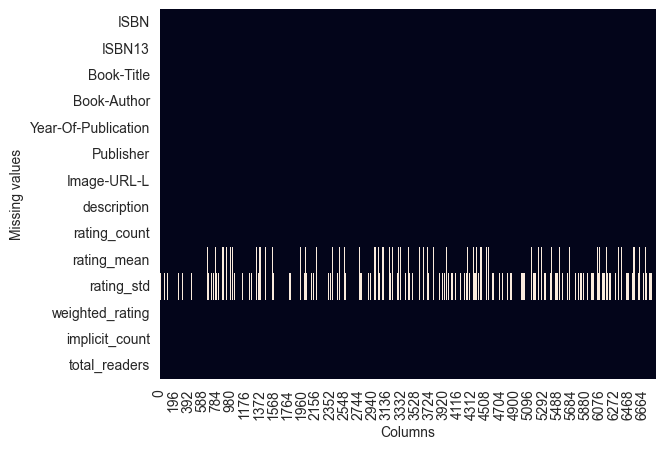

In [4]:
ax = plt.axes()
sns.heatmap(books2.isna().transpose(), cbar=False, ax=ax)

plt.xlabel("Columns")
plt.ylabel("Missing values")

plt.show()

In [7]:
import numpy as np

books2["missing_description"] = np.where(books2["description"].isna(), 1, 0)
books2["age_of_book"] = 2024 - books2["published_year"]

KeyError: 'published_year'